In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json

# 30 Dor Data

In [2]:
# Data from observations

inst = 'MUSE'
pix  = 0.2 #arcsec
dist = 50000 #parsecs
pc   = dist*(2*np.pi) / (360 * 60 * 60)
s0   = (0.9*pc)
pc , s0

(0.24240684055476797, 0.21816615649929116)

# H alfa

In [3]:
name =  "MUSE-Dor-H"
line = "H_I-6563"

In [4]:
_data = json.load(open('observations/'+ name + '-m.json'))
sb    = np.array(_data['sb'])
vv    = np.array(_data['vv'])
ss    = np.array(_data['ss'])

In [5]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv*ss) | (sb < 0.0)

sb[m] = 0.0
vv[m] = np.nanmean(vv)
ss[m] = 0.0
sb /= sb.max()

good = (~m) & (sb > 0.001)

In [6]:
vv_m = np.where(good, vv, np.nan)     
sb_m = np.where(good, sb, np.nan)     
ss_m = np.where(good, ss, np.nan)     

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_12244\2908207673.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


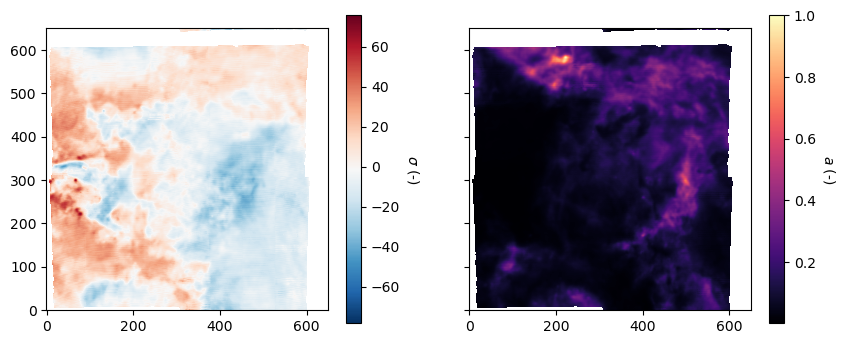

In [7]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv)), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [8]:
trim = (slice(10, 600), slice(30, 590))

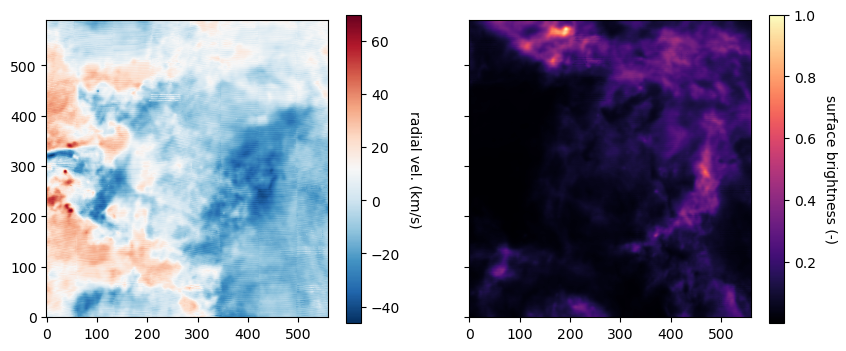

In [9]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv_m))[trim], **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)
im = axx.imshow(sb_m[trim], **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)

In [10]:
N = np.sqrt(vv_m[trim].shape[0] * vv_m[trim].shape[1]) * pix * pc
N

27.867299564396152

In [11]:
sig = np.nanstd(vv_m[trim])
sig

15.662042121713144

In [12]:
hdr = fits.Header()
hdr["INSTR"]      = inst
hdr["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
hdr["sig"]        = (sig, "Standard deviation vel map")
hdr["sig2"]       = (sig**2, "Vel Variance map")
hdr["s0"]         = (s0, "Atmospheric seeing")
#hdr["noise"]     = (noise, "Instrumental noise")
hdr["box_size"]   = (N, "Observational box_size")
hdr["pc"]         = (pc, "parsec convertion")
hdr["pix"]        = (pix, "Instrument pixel scale")
hdr["LINE"]       = (line, "Emission line name")
hdr["BINSIZE"]    = (0, "Spatial binning factor")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")

primary_hdu = fits.PrimaryHDU(header=hdr)
hdu_m0 = fits.ImageHDU(data=sb_m[trim],  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m[trim],  name='MOM1')
hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')

hdul = fits.HDUList([primary_hdu, hdu_m0, hdu_m1, hdu_m2])
hdul.writeto('fits_ready/' + name + '.fits', overwrite=True)

# [NII]

In [13]:
name =  "MUSE-Dor-N"
line = "N_II-"

In [14]:
_data = json.load(open('observations/'+ name + '-m.json'))
sb    = np.array(_data['sb'])
vv    = np.array(_data['vv'])
ss    = np.array(_data['ss'])

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_12244\2269846735.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


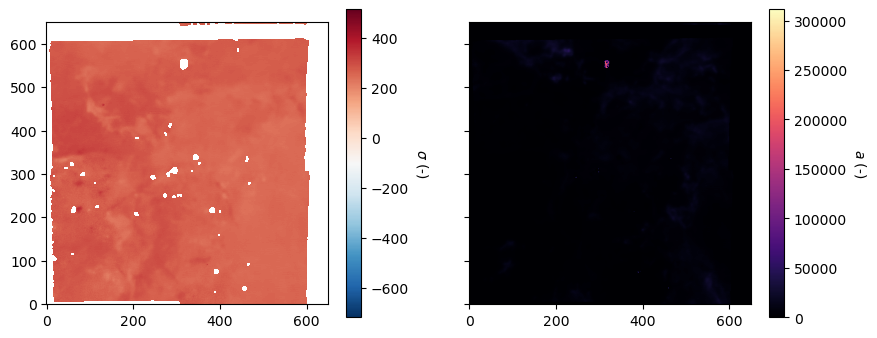

In [15]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [16]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb*vv*ss) | (sb < 0.0)
m = m | (sb > 6e4) 
sb[m] = 0.0
vv[m] = np.nanmean(vv)
ss[m] = 0.0
sb /= sb.max()

mu = vv.mean()
sigma = vv.std()
n = 3

good = (~m) & (sb > 1e-3) & (vv > (mu - n*sigma)) & (vv < (mu + n*sigma))

In [17]:
vv_m = np.where(good, vv, mu)     
sb_m = np.where(good, sb, 0)     
ss_m = np.where(good, ss, np.nan)    

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_12244\2908207673.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


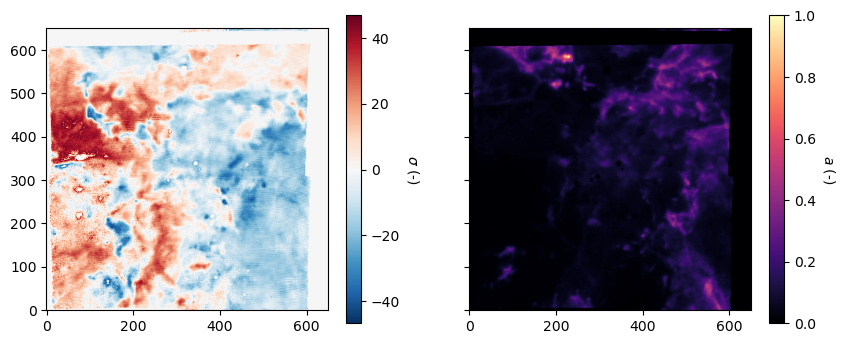

In [18]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv)), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [19]:
trim = (slice(10, 600), slice(30, 590))

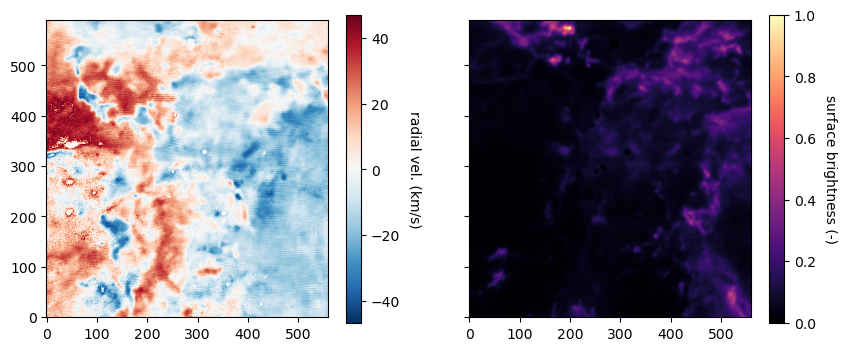

In [20]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow((vv_m-np.nanmean(vv_m))[trim], **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)
im = axx.imshow(sb_m[trim], **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)

In [21]:
N = np.sqrt(vv_m[trim].shape[0] * vv_m[trim].shape[1]) * pix * pc
N

27.867299564396152

In [22]:
sig = np.nanstd(vv_m[trim])
sig

16.39814912832587

In [23]:
hdr = fits.Header()
hdr["INSTR"]      = inst
hdr["AUTHOR"]     = ("J. Garcia-Vazquez", "File creator")
#hdr["m3D"]       = (m3D, "k = 3 + m3D")
#hdr["ra"]        = (ra, "Artificial correlation length")
hdr["sig"]        = (sig, "Standard deviation vel map")
hdr["sig2"]       = (sig**2, "Vel Variance map")
hdr["s0"]         = (s0, "Atmospheric seeing")
#hdr["noise"]     = (noise, "Instrumental noise")
hdr["box_size"]   = (N, "Observational box_size")
hdr["pc"]         = (pc, "parsec convertion")
hdr["pix"]        = (pix, "Instrument pixel scale")
hdr["LINE"]       = (line, "Emission line name")
hdr["BINSIZE"]    = (0, "Spatial binning factor")
#primary.header["SEED1"]     = (randomseed_vv, "Random seed velocity")
#primary.header["SEED2"]     = (randomseed_sb, "Random seed surfavebrightness")

primary_hdu = fits.PrimaryHDU(header=hdr)
hdu_m0 = fits.ImageHDU(data=sb_m[trim],  name='MOM0')
hdu_m1 = fits.ImageHDU(data=vv_m[trim],  name='MOM1')
hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')

hdul = fits.HDUList([primary_hdu, hdu_m0, hdu_m1, hdu_m2])
hdul.writeto('fits_ready/' + name + '.fits', overwrite=True)